# Raw Eye-Tracking Data Inspection

**Goal:**  
Understand the structure, quality, and basic characteristics of the raw eye-tracking data before preprocessing or feature extraction.

**Questions in this notebook:**
- What columns are present?
- What does one trial look like?
- Are there missing values or obvious noise?
- How long are the recordings?

In [1]:
import pandas as pd

file_path = "data/raw/ab36/ab36_GAME0_0.csv"
df = pd.read_csv(file_path)

df.head()

,frame,left_outer_x,left_outer_y,left_center_x,left_center_y,left_inner_x,left_inner_y,right_inner_x,right_inner_y,right_center_x,right_center_y,right_outer_x,right_outer_y,blink,eye
0,327,1668,1414,1719,1404,1796,1415,1979,1405,2046,1385,2098,1389,0,1
1,328,1668,1414,1718,1403,1796,1416,1978,1404,2045,1385,2102,1389,0,1
2,329,1669,1413,1720,1403,1797,1414,1977,1402,2047,1384,2100,1388,0,1
3,330,1669,1413,1719,1403,1797,1414,1978,1403,2047,1384,2100,1387,0,1
4,331,1669,1413,1719,1404,1797,1414,1978,1404,2046,1384,2101,1388,0,1


## Column overview

**Frame / time**
- `frame`: Frame index corresponding to the sampling order of eye-tracking data (proxy for time).

**Left eye keypoints**
- `left_outer_x`, `left_outer_y`: Outer corner of the left eye.
- `left_center_x`, `left_center_y`: Center of the left eye (most stable gaze reference).
- `left_inner_x`, `left_inner_y`: Inner corner of the left eye.

**Right eye keypoints**
- `right_outer_x`, `right_outer_y`: Outer corner of the right eye.
- `right_center_x`, `right_center_y`: Center of the right eye.
- `right_inner_x`, `right_inner_y`: Inner corner of the right eye.

**Eye state indicators**
- `blink`: Binary or scalar indicator of blink events.
- `eye`: Encoded indicator related to eye status or detection state (dataset-specific).

These columns provide frame-level eye position information suitable for trajectory analysis, temporal aggregation, and feature extraction.

In [2]:
df.columns

Index(['frame', 'left_outer_x', 'left_outer_y', 'left_center_x',
       'left_center_y', 'left_inner_x', 'left_inner_y', 'right_inner_x',
       'right_inner_y', 'right_center_x', 'right_center_y', 'right_outer_x',
       'right_outer_y', 'blink', 'eye'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30770 entries, 0 to 30769
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   frame           30770 non-null  int64
 1   left_outer_x    30770 non-null  int64
 2   left_outer_y    30770 non-null  int64
 3   left_center_x   30770 non-null  int64
 4   left_center_y   30770 non-null  int64
 5   left_inner_x    30770 non-null  int64
 6   left_inner_y    30770 non-null  int64
 7   right_inner_x   30770 non-null  int64
 8   right_inner_y   30770 non-null  int64
 9   right_center_x  30770 non-null  int64
 10  right_center_y  30770 non-null  int64
 11  right_outer_x   30770 non-null  int64
 12  right_outer_y   30770 non-null  int64
 13  blink           30770 non-null  int64
 14  eye             30770 non-null  int64
dtypes: int64(15)
memory usage: 3.5 MB


In [4]:
df.isna().sum()

frame             0
left_outer_x      0
left_outer_y      0
left_center_x     0
left_center_y     0
left_inner_x      0
left_inner_y      0
right_inner_x     0
right_inner_y     0
right_center_x    0
right_center_y    0
right_outer_x     0
right_outer_y     0
blink             0
eye               0
dtype: int64

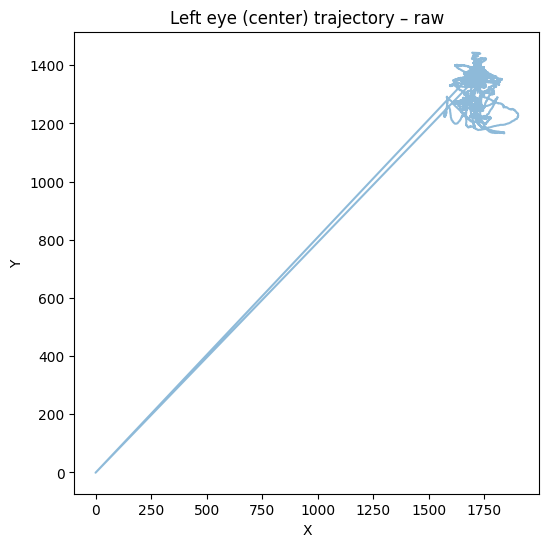

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(df["left_center_x"], df["left_center_y"], alpha=0.5)
plt.title("Left eye (center) trajectory – raw")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

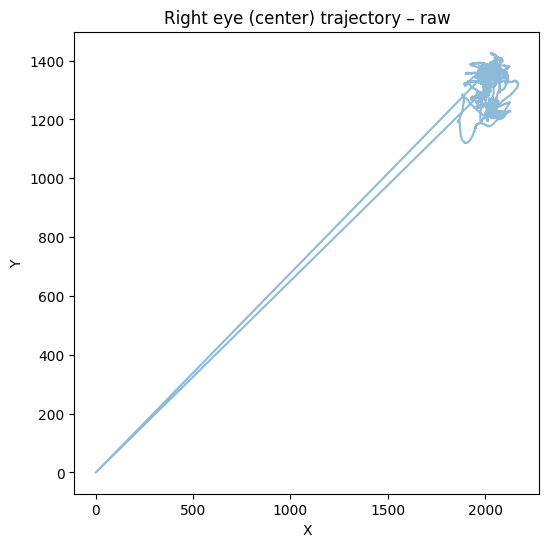

In [8]:
plt.figure(figsize=(6, 6))
plt.plot(df["right_center_x"], df["right_center_y"], alpha=0.5)
plt.title("Right eye (center) trajectory – raw")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

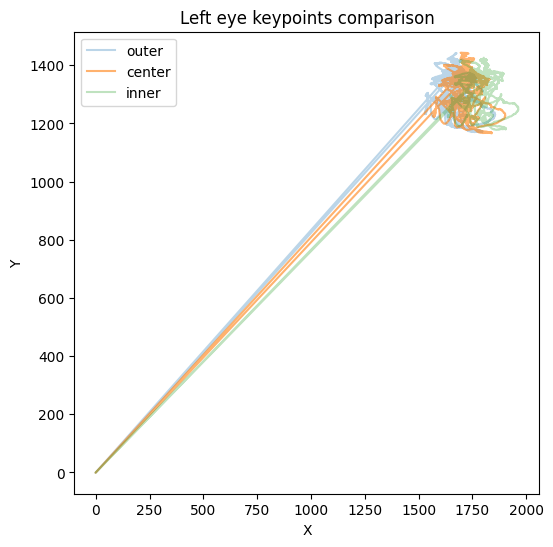

In [9]:
plt.figure(figsize=(6, 6))
plt.plot(df["left_outer_x"], df["left_outer_y"], alpha=0.3, label="outer")
plt.plot(df["left_center_x"], df["left_center_y"], alpha=0.6, label="center")
plt.plot(df["left_inner_x"], df["left_inner_y"], alpha=0.3, label="inner")
plt.legend()
plt.title("Left eye keypoints comparison")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [10]:
df[["left_center_x", "left_center_y"]].std()


left_center_x    53.110947
left_center_y    64.906726
dtype: float64

In [11]:
df[["left_outer_x", "left_outer_y"]].std()

left_outer_x    51.346746
left_outer_y    64.215520
dtype: float64

In [14]:
import numpy as np

In [15]:
vel_center = np.sqrt(np.diff(df["left_center_x"])**2 + np.diff(df["left_center_y"])**2)
vel_inner  = np.sqrt(np.diff(df["left_inner_x"])**2  + np.diff(df["left_inner_y"])**2)
vel_outer  = np.sqrt(np.diff(df["left_outer_x"])**2  + np.diff(df["left_outer_y"])**2)

In [16]:
print("Velocity variance:")
print("center:", np.var(vel_center))
print("inner :", np.var(vel_inner))
print("outer :", np.var(vel_outer))

Velocity variance:
center: 310.2907819214837
inner : 329.9108951266539
outer : 308.21502431344857


### Keypoint comparison and selection

Velocity variance was computed for the inner, center, and outer eye keypoints to assess relative stability. The inner keypoint exhibited the highest variance, indicating greater noise. The center and outer keypoints showed similar variability, with the outer keypoint marginally smoother in this sample.

Despite this, the center eye keypoint is selected for subsequent analyses as it provides a stable and anatomically meaningful approximation of gaze direction, while being less susceptible to eyelid or facial boundary effects than the outer keypoint.

In [17]:
df_clean = df[df["blink"] == 0].copy()
print("Frames before:", len(df))
print("Frames after :", len(df_clean))

Frames before: 30770
Frames after : 30260


In [18]:
x = df_clean["left_center_x"].values
y = df_clean["left_center_y"].values

In [19]:
dx = np.diff(x)
dy = np.diff(y)

velocity = np.sqrt(dx**2 + dy**2)

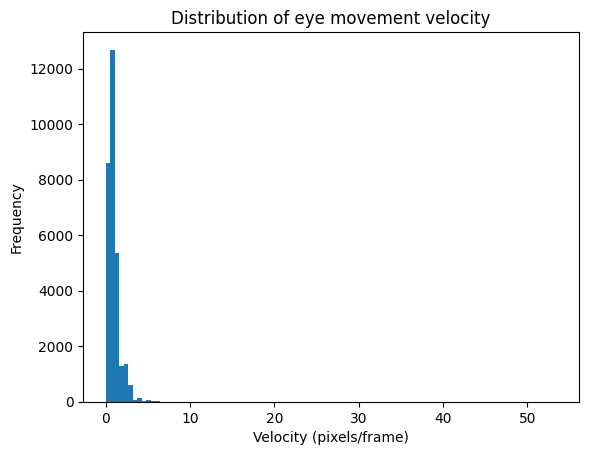

In [20]:
import matplotlib.pyplot as plt

plt.hist(velocity, bins=100)
plt.title("Distribution of eye movement velocity")
plt.xlabel("Velocity (pixels/frame)")
plt.ylabel("Frequency")
plt.show()

### Velocity after blink removal

After removing blink frames, eye movement velocity was recomputed using the left eye center coordinates. The resulting distribution shows a heavy-tailed structure, indicating periods of rapid movement (likely saccades) interspersed with slower motion (fixations).

In [21]:
def moving_average(signal, window=5):
    return np.convolve(signal, np.ones(window)/window, mode="valid")

velocity_smooth = moving_average(velocity, window=5)

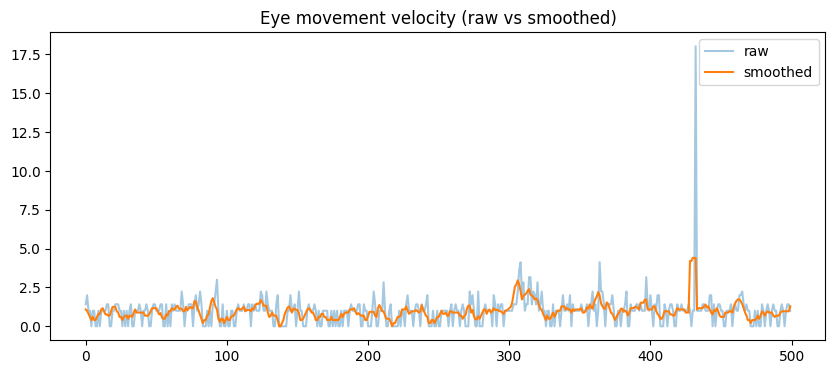

In [22]:
plt.figure(figsize=(10,4))
plt.plot(velocity[:500], alpha=0.4, label="raw")
plt.plot(velocity_smooth[:500], label="smoothed")
plt.legend()
plt.title("Eye movement velocity (raw vs smoothed)")
plt.show()

### Signal smoothing

A short moving-average filter was applied to reduce high-frequency noise while preserving the overall temporal structure of eye movements. This improves the robustness of downstream feature extraction.

In [24]:
import pandas as pd

In [26]:
features = {
    "mean_velocity": np.mean(velocity_smooth),
    "std_velocity": np.std(velocity_smooth),
    "max_velocity": np.max(velocity_smooth),
    "velocity_variance": np.var(velocity_smooth),
}

In [27]:
features_df = pd.DataFrame([features])
features_df

,mean_velocity,std_velocity,max_velocity,velocity_variance
0,0.975538,0.617053,12.762574,0.380754


In [28]:
print(features)

{'mean_velocity': np.float64(0.975537927508354), 'std_velocity': np.float64(0.6170530226175174), 'max_velocity': np.float64(12.76257436032042), 'velocity_variance': np.float64(0.38075443272141446)}
